# Can shared vocabulary fix consensus blind spots? (T8, PART 1 demo)

This notebook demonstrates the **T8 evaluation** (artifact `art_BvAL_KZTZuw8`, iteration 4) from a project on **gold-free quality metrics for NL→FOL autoformalization**.

**Background.** A cross-family *consensus* score checks a candidate FOL formula for a sentence against the formulas that other model families produced for the same sentence (its *peers*). The binary rule **END_MAJ** endorses a candidate when more than half of its family-disjoint peers are equivalent to it. Two error rates describe the rule:
* **e** = P(endorsed | ERROR): wrong formulas the peers agree with (**error endorsement**);
* **d** = P(not endorsed | CORRECT): correct formulas the peers reject (**correct divergence**). The identity AUROC_b = 1 − (e + d)/2 holds.

On dataset E, END_MAJ has a large **d = 0.537**, so more than half of correct candidates are rejected. T8 asks **how much of d a shared vocabulary could remove**. For that, every (candidate, peer) pair gets exactly one class, taken in this order:
`EXACT` (z3-exact equivalent) → `NAME_ONLY` (equivalent after normalising symbol spelling) → `ALIGN_ONLY` (equivalent after predicate alignment) → `VOCAB` (equivalent only under NF/hybrid vocabulary matching) → `IRREDUCIBLE`.
The **counting rules** R_exact, R_align (= END_MAJ), R_name, R_liberal, R_point_MC, R_point_label (the pre-registered PRIMARY prediction, which uses oracle labels) and R_oracle (the no-anchoring floor) then recompute e and d as each class is counted as agreement.

**What runs here.** `eval.py` is an orchestrator that runs 13 scripts under `src/` as subprocesses. Those scripts read absolute paths from earlier experiments and call z3, so they cannot run in Colab. This notebook therefore:
1. shows the orchestrator (`eval.py`) unchanged;
2. runs the **core of PART 1** (`src/t8_part1.py`): gate G0, the per-rule endorsement, e/d with sentence-cluster bootstrap CIs, class shares, the specificity placebo and the c_vres AUROC. The functions are copied verbatim.

It runs on a curated subset of **92 candidate rows from 10 sentences** (878 peer pairs). Sentences with VOCAB pairs were picked on purpose, so VOCAB is over-represented (8% of pairs, against 1.6% in the full data). The z3/matrix pair flags come precomputed in `mini_demo_data.json`.

⚠️ E is *development* data. With only 92 rows, the numbers below illustrate the method; they do not reproduce the full-run values (2,672 rows, 25,358 pairs). The last cell compares the two.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (used by the original eval.py / t8_part1.py)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This cell combines the original import blocks of `eval.py`, `src/t8_part1.py` and eval-2's `stats.py`, and adds matplotlib for the final figure. `multiprocessing`/`ProcessPoolExecutor` (used only for the z3 NAME_ONLY step) and the eval-2 modules that need external files (`consensus_mx`, `frame`, `t8_classes`) are left out.

In [2]:
from __future__ import annotations

# --- eval.py
import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- src/t8_part1.py
import hashlib
import json
from collections import defaultdict

os.environ["PYTHONHASHSEED"] = "0"
import numpy as np
import pandas as pd

# --- eval-2 stats.py
from scipy.stats import rankdata

# --- notebook additions
import types
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data loading
The loader tries the GitHub raw URL first and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EX = data["datasets"][0]["examples"]
print(data["metadata"]["description"])
print(f"{len(EX)} candidate rows, {sum(len(e['peer_pairs']) for e in EX)} peer pairs")

Curated subset of dataset E (R_AB consensus-scorable rows): 92 candidate FOL rows from 10 whole sentences (balanced over strata CTRL/L20/L25/EXC; each sentence has both CORRECT and ERROR candidates, sentences with VOCAB pairs preferred, so VOCAB pairs are over-represented relative to the full data). Each row carries its family-disjoint peer pairs with pair-class flags (EXACT / NAME_ONLY / ALIGN_ONLY / VOCAB / IRREDUCIBLE) precomputed by z3 + eval-2 matrix + exp-8 NF/HYB.
92 candidate rows, 878 peer pairs


## Configuration
All tunable parameters are set here. The demo uses the **original** values: on 92 rows the whole analysis takes about 3 s (about 30 s for the notebook including installs). Lower `B` / `N_MC` / `N_PLACEBO_DRAWS` for a quicker look.
* `B`: sentence-cluster bootstrap replicates for the CIs (original **2000**).
* `N_MC`: Monte-Carlo draws for the probabilistic rules R_point_MC / R_point_label (original **500**).
* `N_PLACEBO_DRAWS`: random-IRREDUCIBLE draws in the specificity placebo (original **200**).
* `N_ROWS`: how many candidate rows of the mini dataset to use (`None` = all 92; the full run has 2,672).

In [5]:
B = 2000                 # bootstrap replicates   (original: B = 2000)
N_MC = 500               # MC draws for R_point_*  (original: N_MC = 500)
N_PLACEBO_DRAWS = 200    # placebo draws           (original: n_draw = 200)
N_ROWS = None             # candidate rows to use   (original: all 2,672 consensus-scorable E rows)

# unchanged constants from src/t8_part1.py
POOL3 = ("deepseek", "microsoft", "openai")
TARGET = {"e": 0.124, "d": 0.537, "auroc_c_exact": 0.748, "auroc_c_align": 0.784}
RULES_DET = ["R_exact", "R_align", "R_name", "R_liberal", "R_oracle", "R_oracle_labdenom"]
RULES_MC = ["R_point_MC", "R_point_label"]
RULES = RULES_DET + RULES_MC

## The orchestrator: `eval.py` (unchanged)
`eval.py` runs the plan's steps in order, one subprocess per script: pre-registration → R_COMP pair matrix → PART 1 (+NET) → PART 3 (power) → PART 2 (R_COMP) → PART 4 (verified record) → figures → audit → `eval_out.json` → `record.md`.

The steps need the full artifact workspace and earlier experiments on disk, so `main()` is **defined but not called** here. The cell prints the plan instead. The rest of the notebook runs the core of the `part1` step inline.

In [6]:
ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

STEPS = [("prereg", ["src/t8_prereg.py"]),
         ("matrix_mini", ["src/t8_run_rcomp_matrix.py", "--stage", "mini"]),
         ("matrix_s50", ["src/t8_run_rcomp_matrix.py", "--stage", "s50"]),
         ("matrix_all", ["src/t8_run_rcomp_matrix.py", "--stage", "all"]),
         ("part1", ["src/t8_part1.py"]), ("part1_net", ["src/t8_part1_net.py"]), ("part3", ["src/t8_part3.py"]),
         ("part2", ["src/t8_part2.py"]), ("part4", ["src/t8_part4.py"]), ("figs", ["src/t8_figs.py"]),
         ("audit", ["audit/rederive.py"]), ("eval_out", ["src/t8_eval_out.py"]), ("record_md", ["src/t8_record_md.py"])]


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--skip-matrix", action="store_true", help="reuse results/pair_matrix_RCOMP.jsonl")
    ap.add_argument("--from", dest="start", default="prereg", choices=[s for s, _ in STEPS])
    a = ap.parse_args()
    env = dict(os.environ, PYTHONHASHSEED="0", PYTHONDONTWRITEBYTECODE="1")
    names = [s for s, _ in STEPS]
    for name, cmd in STEPS[names.index(a.start):]:
        if a.skip_matrix and name.startswith("matrix"):
            continue
        t0 = time.time()
        logger.info(f"step {name}: {' '.join(cmd)}")
        subprocess.run([sys.executable, *cmd], cwd=ROOT, env=env, check=True)
        logger.info(f"step {name} done in {time.time() - t0:.0f}s")


# Notebook: main() spawns src/*.py scripts that are not shipped with the demo, so print the plan instead of running it.
for name, cmd in STEPS:
    print(f"{name:12s} -> python {' '.join(cmd)}")

prereg       -> python src/t8_prereg.py
matrix_mini  -> python src/t8_run_rcomp_matrix.py --stage mini
matrix_s50   -> python src/t8_run_rcomp_matrix.py --stage s50
matrix_all   -> python src/t8_run_rcomp_matrix.py --stage all
part1        -> python src/t8_part1.py
part1_net    -> python src/t8_part1_net.py
part3        -> python src/t8_part3.py
part2        -> python src/t8_part2.py
part4        -> python src/t8_part4.py
figs         -> python src/t8_figs.py
audit        -> python audit/rederive.py
eval_out     -> python src/t8_eval_out.py
record_md    -> python src/t8_record_md.py


## eval-2 statistics helpers (imported unchanged in T8)
T8 imports these from the eval-2 workspace unchanged (code sha `dd73975642f428cc`). They are copied here verbatim:
* `auc`: tie-aware Mann-Whitney AUROC; `strat_auc`: within-stratum pair-weighted AUROC;
* `ci`: percentile interval; `WAuc` / `WStratAuc`: the same AUROCs under bootstrap row weights;
* `SentBoot`: sentence-cluster bootstrap as a (B × rows) multiplicity-weight matrix;
* `ed_decomposition` (from `mechanism.py`): computes e, d and AUROC_b and asserts AUROC_b = 1 − (e + d)/2.

`MC` is a small namespace that stands in for `import mechanism as MC`, so the Part-1 code below keeps its `MC.` calls unchanged.

In [7]:
B_DEFAULT = 2000


def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement)."""

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        """(B, n_rows[mask]) weight matrix."""
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


# --- mechanism.py
MIN_ROWS, MIN_SENT = 30, 10


def ed_decomposition(y, endorsed) -> dict:
    """y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy)."""
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}


MC = types.SimpleNamespace(ed_decomposition=ed_decomposition, MIN_ROWS=MIN_ROWS, MIN_SENT=MIN_SENT)

## Build P (candidate rows) and Q (candidate × family-disjoint peer pairs)
In the original, `load()` + `build_pairs()` read the eval-2 equivalence matrix (`pairwise_classes_E.jsonl`), `add_name_only()` runs z3 on symbol-normalised formulas, and `add_pairs_E()` joins the exp-8 NF/HYB results. In `mini_demo_data.json` those per-pair flags (`f_exact`, `f_align`, `f_name`, `f_vocab_raw`) are already stored with each row. The cell below rebuilds the same `P` and `Q` DataFrames from them.

The original `classify()` then **recomputes** the pair class from the flags using the pre-registered precedence, and the result is checked against the stored class.

In [8]:
EXs = EX if N_ROWS is None else EX[:N_ROWS]
P = pd.DataFrame([{k: v for k, v in e.items() if k != "peer_pairs"} for e in EXs])
Q = pd.DataFrame([{"sentence_id": e["sentence_id"], "cand": e["row_key"], **p} for e in EXs for p in e["peer_pairs"]])
P["long"] = P["long"].astype(bool)
P["in_RAB"] = True
P["end_maj_frozen"] = (P.c_frozen_raw < 0.5).astype(int)
Q["stratum"] = Q.cand.map(dict(zip(P.row_key, P.stratum)))
stored_cls = Q.pop("cls")
Q = Q.drop(columns=["f_vocab_extra", "in_pool3"])   # recomputed by classify()
print(f"P {len(P)} rows ({P.sentence_id.nunique()} sentences), Q {len(Q)} pairs")
print(P.stratum.value_counts().to_dict(), "| labels:", P.y_AB.map({0: 'CORRECT', 1: 'ERROR'}).value_counts().to_dict())

P 92 rows (10 sentences), Q 878 pairs
{'L20': 24, 'CTRL': 24, 'L25': 22, 'EXC': 22} | labels: {'ERROR': 63, 'CORRECT': 29}


In [9]:
def classify(Q: pd.DataFrame) -> None:
    Q["cls"] = np.select([Q.f_exact, Q.f_name, Q.f_align, Q.f_vocab_raw],
                         ["EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB"], "IRREDUCIBLE")
    Q["f_vocab_extra"] = Q.cls == "VOCAB"
    Q["in_pool3"] = Q.peer_family.isin(POOL3)


classify(Q)
print("classify() reproduces the stored pair classes:", bool((Q.cls.values == stored_cls.values).all()))
print(Q.cls.value_counts().to_dict())

classify() reproduces the stored pair classes: True
{'IRREDUCIBLE': 526, 'ALIGN_ONLY': 233, 'VOCAB': 71, 'EXACT': 48}


## Gate G0: does the matrix reproduce END_MAJ?
`gate_g0` (verbatim) recomputes e and d of END_MAJ from the eval-2 matrix, plus the AUROCs of the graded consensus scores `c_exact` and `c_align` (the fraction of peers that are not equivalent to the candidate). On the full 2,672 rows it must hit the targets within 0.002. On this 92-row subset the values differ, so the demo prints the gate but does not stop on it. (The original raises `SystemExit("G0 failed")`.)

In [10]:
def gate_g0(P: pd.DataFrame) -> dict:
    y = P.y_AB.values.astype(int)
    ed = MC.ed_decomposition(y, P.end_maj_mx.values.astype(int))
    g = {"n_scorable": len(P), "n_err": ed["n_err"], "n_cor": ed["n_cor"], "n_sent": int(P.sentence_id.nunique()),
         "e_END_MAJ_matrix": ed["e"], "d_END_MAJ_matrix": ed["d"],
         "e_END_MAJ_frozen": float(P.end_maj_frozen[y == 1].mean()), "d_END_MAJ_frozen": float(1 - P.end_maj_frozen[y == 0].mean()),
         "auroc_c_exact": auc(y, P.c_exact.values), "auroc_c_align_frozen": auc(y, P.c_frozen.values),
         "auroc_c_align_matrix": auc(y, P.c_re.values), "targets": TARGET, "tolerance": 0.002}
    g["pass"] = (abs(g["e_END_MAJ_matrix"] - TARGET["e"]) <= 0.002 and abs(g["d_END_MAJ_matrix"] - TARGET["d"]) <= 0.002
                 and abs(g["auroc_c_exact"] - TARGET["auroc_c_exact"]) <= 0.002
                 and abs(g["auroc_c_align_frozen"] - TARGET["auroc_c_align"]) <= 0.002)
    g["n_rows_end_maj_matrix_ne_frozen"] = int((P.end_maj_mx != P.end_maj_frozen).sum())
    return g


G0 = gate_g0(P)
for k in ("n_scorable", "n_err", "n_cor", "n_sent", "e_END_MAJ_matrix", "d_END_MAJ_matrix", "auroc_c_exact", "auroc_c_align_frozen", "pass"):
    print(f"{k:22s} {G0[k]}")
print("(full-run targets:", TARGET, ")")

n_scorable             92
n_err                  63
n_cor                  29
n_sent                 10
e_END_MAJ_matrix       0.23809523809523808
d_END_MAJ_matrix       0.6551724137931034
auroc_c_exact          0.6912972085385879
auroc_c_align_frozen   0.5960591133004927
pass                   False
(full-run targets: {'e': 0.124, 'd': 0.537, 'auroc_c_exact': 0.748, 'auroc_c_align': 0.784} )


## Counting rules: endorsement per candidate
* `endorse_det` covers the deterministic rules. A candidate is endorsed iff #agreeing peers > npc/2, where each rule counts a different set of classes as agreement: `R_exact` EXACT; `R_align` +ALIGN (= END_MAJ); `R_name` +NAME_ONLY; `R_liberal` +every VOCAB pair; `R_oracle` uses peer labels only (no anchoring).
* `endorse_mc` covers `R_point_MC`, which accepts each VOCAB pair with the pre-registered probability p = 0.612, and `R_point_label`, which accepts VOCAB pairs by label agreement, or with p = 0.612 when the peer is unlabelled. Both draw `N_MC` Monte-Carlo samples.

Pools: `9fam` uses all family-disjoint peers. `3pool` (PRIMARY) keeps only peers from deepseek / microsoft / openai.

In [11]:
def endorse_det(Q: pd.DataFrame, P: pd.DataFrame, pool: str) -> tuple[dict, np.ndarray]:
    """Deterministic endorsement per rule for every P row (NaN when the pool has no rows)."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    y = P.y_AB.values.astype(int)
    cand_opc = P.row_key.map(dict(zip(Q.cand, Q.cand_opc))).values
    agree = {
        "R_exact": q.f_exact.values, "R_align": q.f_align.values, "R_name": (q.f_align | q.f_name).values,
        "R_liberal": (q.f_align | q.f_name | q.f_vocab_raw).values}
    peer_y = q.peer_y.values
    cy = y[ci_]
    lab_agree = np.where(cy == 0, peer_y == 0, (peer_y == 1) & (q.peer_opc.values == cand_opc[ci_]))
    agree["R_oracle"] = lab_agree
    labelled = np.array([v in (0, 1) for v in peer_y])
    out = {}
    with np.errstate(invalid="ignore", divide="ignore"):
        for r, a in agree.items():
            k = np.bincount(ci_, weights=a.astype(float), minlength=len(P))
            out[r] = np.where(n > 0, (k > n / 2).astype(float), np.nan)
        k = np.bincount(ci_, weights=lab_agree.astype(float), minlength=len(P))
        nl = np.bincount(ci_, weights=labelled.astype(float), minlength=len(P))
        out["R_oracle_labdenom"] = np.where(nl > 0, (k > nl / 2).astype(float), np.nan)
        out["_n"] = n
        out["_agree_liberal"] = np.bincount(ci_, weights=agree["R_liberal"].astype(float), minlength=len(P))
        out["_agree_align"] = np.bincount(ci_, weights=agree["R_align"].astype(float), minlength=len(P))
    return out, ci_


def endorse_mc(Q: pd.DataFrame, P: pd.DataFrame, pool: str, p_acc: float, seed: int = 0) -> dict:
    """(N_MC, n_rows) endorsement draws for R_point_MC and R_point_label."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    base = np.bincount(ci_, weights=(q.f_align | q.f_name).values.astype(float), minlength=len(P))
    vx = q.f_vocab_extra.values
    y = P.y_AB.values.astype(int)
    cy = y[ci_]
    peer_y = q.peer_y.values
    cand_opc = P.row_key.map(dict(zip(Q.cand, Q.cand_opc))).values[ci_]
    unl = np.array([v not in (0, 1) for v in peer_y])
    acc_lab = np.where(cy == 0, peer_y == 0, (peer_y == 1) & (q.peer_opc.values == cand_opc))
    p_label = np.where(unl, p_acc, acc_lab.astype(float))
    rng = np.random.default_rng(seed)
    vi = np.where(vx)[0]
    U = rng.random((N_MC, len(vi)))
    out = {}
    for name, prob in (("R_point_MC", np.full(len(vi), p_acc)), ("R_point_label", p_label[vi])):
        acc = (U < prob[None, :]).astype(float)
        K = np.zeros((N_MC, len(P)))
        np.add.at(K.T, ci_[vi], acc.T)
        with np.errstate(invalid="ignore"):
            out[name] = np.where(n[None, :] > 0, ((base[None, :] + K) > n[None, :] / 2).astype(float), np.nan)
    return out

## e / d summaries with sentence-cluster CIs
`ed_ci` returns e, d, AUROC_b and bootstrap CIs; for MC rules it also returns the MC band. `rule_tables` repeats this for every rule and every cut: words tercile, number of conditions, stratum, and the long-sentence pool.

In [12]:
def ed_ci(y, en, W) -> dict:
    """e, d, AUROC_b with sentence-cluster CIs. en: (n,) binary or (N_MC, n) draws (combined band: replicate b uses
    draw b % N_MC)."""
    y = np.asarray(y, int)
    if en.ndim == 1:
        e = float(en[y == 1].mean()) if (y == 1).any() else np.nan
        d = float(1 - en[y == 0].mean()) if (y == 0).any() else np.nan
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W @ (en * y)) / (W @ y)
            db = (W @ ((1 - en) * (1 - y))) / (W @ (1 - y))
        rec = {"e": e, "d": d}
    else:
        e = float(np.nanmean(en[:, y == 1].mean(1))) if (y == 1).any() else np.nan
        d = float(np.nanmean(1 - en[:, y == 0].mean(1))) if (y == 0).any() else np.nan
        M = en[np.arange(W.shape[0]) % en.shape[0]]
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W * M * y).sum(1) / (W @ y)
            db = (W * (1 - M) * (1 - y)).sum(1) / (W @ (1 - y))
        rec = {"e": e, "d": d, "mc_band_e": [float(np.percentile(en[:, y == 1].mean(1), 2.5)), float(np.percentile(en[:, y == 1].mean(1), 97.5))] if (y == 1).any() else [None, None],
               "mc_band_d": [float(np.percentile(1 - en[:, y == 0].mean(1), 2.5)), float(np.percentile(1 - en[:, y == 0].mean(1), 97.5))] if (y == 0).any() else [None, None]}
    rec.update({"auroc_b": 1 - (e + d) / 2, "e_ci": ci(eb), "d_ci": ci(db), "auroc_b_ci": ci(1 - (eb + db) / 2),
                "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum())})
    return rec


def cut_labels(P: pd.DataFrame) -> dict:
    return {"ALL": np.array(["ALL"] * len(P), object), "words_tercile": P.words_t.values, "ncond_bin": P.ncond_bin.values,
            "stratum": P.stratum.values, "long_pool": np.where(P.long.values, "L25+L20+EXC", None)}


def rule_tables(P: pd.DataFrame, EN: dict, boot: SentBoot, pool: str) -> tuple[pd.DataFrame, dict]:
    """e/d per rule and cut. EN: rule -> (n,) or (N_MC, n) with NaN = not scorable in this pool."""
    Wf = boot.W()
    y_all = P.y_AB.values.astype(int)
    rows = []
    heads = {}
    for rule in RULES:
        en_all = EN[rule]
        ok = ~np.isnan(en_all if en_all.ndim == 1 else en_all[0])
        for dim, lab in cut_labels(P).items():
            for val in sorted({v for v in lab if v is not None}):
                m = ok & (lab == val)
                if m.sum() == 0:
                    continue
                y = y_all[m]
                en = en_all[m] if en_all.ndim == 1 else en_all[:, m]
                rec = ed_ci(y, en, Wf[:, m])
                ns = int(P.sentence_id.values[m].size and len(set(P.sentence_id.values[m])))
                rec.update({"pool": pool, "rule": rule, "dim": dim, "cell": val, "n_sent": ns,
                            "testable_d": bool(rec["n_cor"] >= MC.MIN_ROWS and ns >= MC.MIN_SENT),
                            "testable_e": bool(rec["n_err"] >= MC.MIN_ROWS and ns >= MC.MIN_SENT)})
                if en.ndim == 1:
                    ed = MC.ed_decomposition(y, en.astype(int)) if (y == 1).any() and (y == 0).any() else None
                    rec["identity_ok"] = ed is not None
                rows.append(rec)
                if dim == "ALL":
                    heads[rule] = rec
    T = pd.DataFrame(rows)
    return T, heads

## Class shares, specificity placebo, c_vres
* `class_shares`: class shares of all pairs, of CORRECT-candidate pairs, of ERROR-candidate pairs and of *disagreeing* CORRECT-candidate pairs, each split by the peer's own label.
* `placebo`: adds random IRREDUCIBLE pairs as agreements, the same number per sentence as the VOCAB pairs. The ratio (Δd/Δe for VOCAB) ÷ (Δd/Δe for random pairs) tests whether VOCAB agreements are label-specific: well above 1 means they are, about 1 means they are indiscriminate.
* `cvres`: a graded, gold-free score c_vres = 1 − (liberal agreements)/npc, compared by AUROC against the frozen c_score_align.

`gee_slopes` from the original is omitted: it needs statsmodels GEE fits from eval-2's `mechanism.py`.

In [13]:
def placebo(P: pd.DataFrame, Q: pd.DataFrame, EN: dict, pool: str, boot: SentBoot, n_draw: int = 200) -> dict:
    """Random IRREDUCIBLE pairs (same count per sentence as VOCAB pairs) counted as agreements on top of R_name."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    base = np.bincount(ci_, weights=(q.f_align | q.f_name).values.astype(float), minlength=len(P))
    y = P.y_AB.values.astype(int)
    en_name = EN["R_name"]
    en_lib = EN["R_liberal"]
    ok = ~np.isnan(en_name)
    sid = q.sentence_id.values
    irr = np.where((q.cls == "IRREDUCIBLE").values)[0]
    by_irr = defaultdict(list)
    for i in irr:
        by_irr[sid[i]].append(i)
    kv = defaultdict(int)
    for s in sid[q.f_vocab_extra.values]:
        kv[s] += 1
    rng = np.random.default_rng(0)
    draws = []
    n_capped = 0
    for _ in range(n_draw):
        extra = np.zeros(len(P))
        for s, k in kv.items():
            pool_i = by_irr.get(s, [])
            if len(pool_i) < k:
                n_capped += 1
            pick = rng.choice(pool_i, size=min(k, len(pool_i)), replace=False) if pool_i else []
            np.add.at(extra, ci_[pick], 1.0)
        with np.errstate(invalid="ignore"):
            draws.append(np.where(n > 0, ((base + extra) > n / 2).astype(float), np.nan))
    R = np.array(draws)
    W = boot.W()[:, ok]
    yk = y[ok]

    def dd(en):  # d, e for binary vector or rows
        return (1 - en[..., yk == 0]).mean(-1), en[..., yk == 1].mean(-1)
    d_n, e_n = dd(en_name[ok])
    d_l, e_l = dd(en_lib[ok])
    d_r, e_r = dd(R[:, ok])
    dV, eV = d_n - d_l, e_l - e_n
    dR, eR = d_n - d_r, e_r - e_n
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = (dV / eV) / (np.mean(dR) / np.mean(eR))
    # bootstrap: replicate b uses placebo draw b % n_draw
    rb = []
    Rk = R[:, ok]
    for b in range(W.shape[0]):
        w = W[b]
        w0, w1 = w * (yk == 0), w * (yk == 1)
        if w0.sum() == 0 or w1.sum() == 0:
            continue

        def de(en):
            return (w0 @ (1 - en)) / w0.sum(), (w1 @ en) / w1.sum()
        dn, en_ = de(en_name[ok])
        dl, el = de(en_lib[ok])
        dr, er = de(Rk[b % n_draw])
        with np.errstate(invalid="ignore", divide="ignore"):
            rb.append(((dn - dl) / (el - en_)) / ((dn - dr) / (er - en_)))
    rb = np.array(rb)
    return {"pool": pool, "n_vocab_pairs": int(sum(kv.values())), "n_sentences_with_vocab": len(kv),
            "n_sentence_draws_capped": n_capped, "delta_d_vocab": float(dV), "delta_e_vocab": float(eV),
            "delta_d_random_mean": float(np.mean(dR)), "delta_e_random_mean": float(np.mean(eR)),
            "delta_d_random_band": [float(np.percentile(dR, 2.5)), float(np.percentile(dR, 97.5))],
            "delta_e_random_band": [float(np.percentile(eR, 2.5)), float(np.percentile(eR, 97.5))],
            "specificity_ratio": float(ratio), "specificity_ratio_ci": ci(rb[np.isfinite(rb)]),
            "n_boot_finite": int(np.isfinite(rb).sum()),
            "reading": "ratio well above 1 = VOCAB agreements concentrated among CORRECT candidates; ~1 = indiscriminate"}


def class_shares(P: pd.DataFrame, Q: pd.DataFrame, pool: str) -> pd.DataFrame:
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    ymap = dict(zip(P.row_key, P.y_AB.astype(int)))
    q = q.assign(cand_y=q.cand.map(ymap), peer_lab=q.peer_y.map({0: "CORRECT", 1: "ERROR"}).fillna("unlabelled"))
    sets = {"all_pairs": q, "CORRECT_cand_pairs": q[q.cand_y == 0], "ERROR_cand_pairs": q[q.cand_y == 1],
            "disagreeing_CORRECT_cand_pairs": q[(q.cand_y == 0) & ~q.f_align]}
    rows = []
    for nm, s in sets.items():
        for pl in ("ALL", "CORRECT", "ERROR", "unlabelled"):
            ss = s if pl == "ALL" else s[s.peer_lab == pl]
            if len(ss) == 0:
                continue
            vc = ss.cls.value_counts()
            rows.append({"pool": pool, "pair_set": nm, "peer_label": pl, "n_pairs": len(ss), "n_sent": ss.sentence_id.nunique(),
                         **{f"share_{c}": float(vc.get(c, 0) / len(ss)) for c in ("EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE")}})
    return pd.DataFrame(rows)


def cvres(P: pd.DataFrame, D: dict, boot: SentBoot, pool: str) -> dict:
    n = D["_n"]
    ok = n > 0
    c_v = np.where(ok, 1 - D["_agree_liberal"] / np.where(ok, n, 1), np.nan)
    c_a = np.where(ok, 1 - D["_agree_align"] / np.where(ok, n, 1), np.nan)
    P[f"c_vres_{pool}"] = c_v
    P[f"c_align_{pool}"] = c_a
    out = {}
    for cell, m0 in (("R_AB", np.ones(len(P), bool)), ("L25", P.stratum.values == "L25"), ("long", P.long.values)):
        m = m0 & ok
        y = P.y_AB.values[m].astype(int)
        st = P.stratum.values[m]
        W = boot.W(m)
        rec = {"n": int(m.sum()), "n_err": int(y.sum()), "n_cor": int((1 - y).sum())}
        for nm, s in (("c_vres", c_v[m]), ("c_align_pool", c_a[m]), ("c_score_align_frozen", P.c_frozen.values[m])):
            rec[f"auroc_{nm}"] = auc(y, s)
            rec[f"strat_auroc_{nm}"] = strat_auc(y, s, st)
        wv, wa = WAuc(y, c_v[m]), WAuc(y, P.c_frozen.values[m])
        sv, sa = WStratAuc(y, c_v[m], st), WStratAuc(y, P.c_frozen.values[m], st)
        rec["delta_auroc_vres_minus_frozen_ci"] = ci([wv(W[b]) - wa(W[b]) for b in range(W.shape[0])])
        rec["delta_strat_auroc_vres_minus_frozen_ci"] = ci([sv(W[b]) - sa(W[b]) for b in range(W.shape[0])])
        rec["delta_auroc_vres_minus_frozen"] = rec["auroc_c_vres"] - rec["auroc_c_score_align_frozen"]
        rec["delta_strat_auroc_vres_minus_frozen"] = rec["strat_auroc_c_vres"] - rec["strat_auroc_c_score_align_frozen"]
        out[cell] = rec
    return out

## Run PART 1 on the subset
This is the pool loop of `t8_part1.main()`, copied as-is except that the GEE step and the file writes (`part1.json`, CSVs, pickles) are dropped. `p_acc` comes from the pre-registration (`prereg_d_split.json`, stored in the data metadata).

In [14]:
t0 = time.time()
p_acc = float(data["metadata"]["p_accept_vocab"])
Q["in_pool3"] = Q.peer_family.isin(POOL3)
A = {"p_accept_vocab": p_acc, "G0": G0}
boot = SentBoot(P.sentence_id.values, b=B, seed=0)
A["pools"] = {}
ENs = {}
tabs = []
shares = []
for pool in ("3pool", "9fam"):
    D, _ = endorse_det(Q, P, pool)
    EN = {r: D[r] for r in RULES_DET}
    EN.update(endorse_mc(Q, P, pool, p_acc))
    ENs[pool] = EN
    T, heads = rule_tables(P, EN, boot, pool)
    tabs.append(T)
    shares.append(class_shares(P, Q, pool))
    d0, e0 = heads["R_align"]["d"], heads["R_align"]["e"]
    pr = {"n_rows_scorable": int((D["_n"] > 0).sum()), "n_rows_excluded_no_pool_rows": int((D["_n"] == 0).sum()),
          "heads": heads,
          "d_floor_pred": heads["R_point_label"]["d"], "d_floor_pred_ci": heads["R_point_label"]["d_ci"],
          "d_bracket": [heads["R_liberal"]["d"], heads["R_name"]["d"]],
          "d_R_exact": heads["R_exact"]["d"], "d_R_oracle": heads["R_oracle"]["d"], "d_R_oracle_labdenom": heads["R_oracle_labdenom"]["d"],
          "d_R_point_MC": heads["R_point_MC"]["d"],
          "e_ceiling_pred": heads["R_point_label"]["e"], "e_ceiling_pred_ci": heads["R_point_label"]["e_ci"],
          "e_bracket": [heads["R_name"]["e"], heads["R_liberal"]["e"]],
          "d_END_MAJ_this_pool": d0, "e_END_MAJ_this_pool": e0}
    dfl = pr["d_floor_pred"]
    pr["decision_rule"] = {"d_matched": d0, "d_floor_pred_matched": dfl,
                           "d_CSC_for_gap_0.67": d0 - 0.67 * (d0 - dfl), "d_CSC_for_gap_0.33": d0 - 0.33 * (d0 - dfl),
                           "anchoring_floor_d_R_oracle": heads["R_oracle"]["d"]}
    logger.info(f"[{pool}] d: align {d0:.3f} exact {pr['d_R_exact']:.3f} name {heads['R_name']['d']:.3f} "
                f"point_label {dfl:.3f} liberal {heads['R_liberal']['d']:.3f} oracle {pr['d_R_oracle']:.3f}; "
                f"e: align {e0:.3f} point_label {pr['e_ceiling_pred']:.3f} liberal {heads['R_liberal']['e']:.3f}")
    pr["placebo"] = placebo(P, Q, EN, pool, boot, n_draw=N_PLACEBO_DRAWS)
    logger.info(f"[{pool}] placebo {pr['placebo']['specificity_ratio']:.3f} {pr['placebo']['specificity_ratio_ci']}")
    pr["c_vres"] = cvres(P, D, boot, pool)
    A["pools"][pool] = pr
    for r in RULES:
        en = EN[r]
        P[f"en_{pool}_{r}"] = en if en.ndim == 1 else en.mean(0)
    P[f"en_{pool}_R_point_label_draw0"] = EN["R_point_label"][0]
T = pd.concat(tabs, ignore_index=True)
A["n_pairs_by_class"] = {k: int(v) for k, v in Q.cls.value_counts().items()}
A["n_pairs_by_class_3pool"] = {k: int(v) for k, v in Q[Q.in_pool3].cls.value_counts().items()}
A["wall_s"] = round(time.time() - t0, 1)
logger.info(f"PART 1 (demo subset) done in {A['wall_s']}s")

13:21:13|INFO   |[3pool] d: align 0.724 exact 1.000 name 0.724 point_label 0.621 liberal 0.552 oracle 0.621; e: align 0.242 point_label 0.268 liberal 0.323


13:21:13|INFO   |[3pool] placebo 5.231 [0.0, 25.030357142857195]


13:21:14|INFO   |[9fam] d: align 0.655 exact 1.000 name 0.655 point_label 0.586 liberal 0.517 oracle 0.724; e: align 0.238 point_label 0.280 liberal 0.333


13:21:14|INFO   |[9fam] placebo 2.255 [0.0, 16.000000000000018]


13:21:15|INFO   |PART 1 (demo subset) done in 2.5s


## Results
The tables below give e and d per counting rule and pool on the subset, with bootstrap CIs, next to the **full-run** values from `eval_out.json` (2,672 rows, B = 2000, N_MC = 500).

How to read them: going down the list (R_exact → R_align → R_name → R_point_label → R_liberal), each rule counts more pair classes as agreement, so d can only fall and e can only rise. In the full run, vocabulary fixes (the R_align → R_point_label / R_liberal gap) remove little of d (3-pool 0.415 → 0.402 → 0.396). Even the label oracle leaves d at 0.385. The consensus blind spot is mostly *irreducible* disagreement, not vocabulary.

In [15]:
REF = data["metadata"]["full_run_reference_metrics"]
SHOW = ["R_exact", "R_align", "R_name", "R_point_MC", "R_point_label", "R_liberal", "R_oracle", "R_oracle_labdenom"]
rows = []
for pool in ("3pool", "9fam"):
    h = A["pools"][pool]["heads"]
    for r in SHOW:
        rows.append({"pool": pool, "rule": r, "n_err": h[r]["n_err"], "n_cor": h[r]["n_cor"],
                     "e_demo": h[r]["e"], "e_ci": h[r]["e_ci"], "d_demo": h[r]["d"], "d_ci": h[r]["d_ci"],
                     "e_full": REF.get(f"p1_e_{r}_{pool}"), "d_full": REF.get(f"p1_d_{r}_{pool}")})
R = pd.DataFrame(rows)
fmt = lambda v: "NA" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"
fci = lambda c: "[" + ", ".join(fmt(x) for x in c) + "]"
print(R.assign(e_demo=R.e_demo.map(fmt), e_ci=R.e_ci.map(fci), d_demo=R.d_demo.map(fmt), d_ci=R.d_ci.map(fci),
               e_full=R.e_full.map(fmt), d_full=R.d_full.map(fmt)).to_string(index=False))

print("\nPair classes (demo subset):", A["n_pairs_by_class"], "| 3pool:", A["n_pairs_by_class_3pool"])
for pool in ("3pool", "9fam"):
    pp = A["pools"][pool]
    print(f"\n[{pool}] d_floor_pred (R_point_label) {fmt(pp['d_floor_pred'])} {fci(pp['d_floor_pred_ci'])}"
          f"  | full run {fmt(REF.get(f'p1_d_floor_pred_{pool}'))}")
    print(f"[{pool}] gap-rule denominator d_matched - d_floor_pred = {fmt(pp['decision_rule']['d_matched'] - pp['decision_rule']['d_floor_pred_matched'])}"
          f"  | full run {fmt(REF.get(f'p1_gap_rule_denominator_{pool}'))}")
    print(f"[{pool}] specificity ratio {fmt(pp['placebo']['specificity_ratio'])} {fci(pp['placebo']['specificity_ratio_ci'])}"
          f"  | full run {fmt(REF.get(f'p1_specificity_ratio_{pool}'))}")
    cv = pp["c_vres"]["R_AB"]
    print(f"[{pool}] AUROC c_vres {fmt(cv['auroc_c_vres'])} vs c_score_align {fmt(cv['auroc_c_score_align_frozen'])}"
          f"  (delta {fmt(cv['delta_auroc_vres_minus_frozen'])} {fci(cv['delta_auroc_vres_minus_frozen_ci'])})"
          f"  | full run delta {fmt(REF.get(f'p1_c_vres_minus_c_align_auroc_R_AB_{pool}'))}")

sh = pd.concat(shares, ignore_index=True)
print("\nClass shares of DISAGREEING pairs of CORRECT candidates, by peer label (demo):")
print(sh[sh.pair_set == "disagreeing_CORRECT_cand_pairs"].round(3).to_string(index=False))

 pool              rule  n_err  n_cor e_demo           e_ci d_demo           d_ci e_full d_full
3pool           R_exact     62     29  0.000 [0.000, 0.000]  1.000 [1.000, 1.000]  0.024  0.683
3pool           R_align     62     29  0.242 [0.000, 0.500]  0.724 [0.484, 0.966]  0.157  0.415
3pool            R_name     62     29  0.242 [0.000, 0.500]  0.724 [0.484, 0.966]  0.157  0.415
3pool        R_point_MC     62     29  0.272 [0.000, 0.532]  0.635 [0.368, 0.909]  0.164  0.405
3pool     R_point_label     62     29  0.268 [0.019, 0.519]  0.621 [0.367, 0.897]  0.162  0.402
3pool         R_liberal     62     29  0.323 [0.048, 0.580]  0.552 [0.286, 0.846]  0.171  0.396
3pool          R_oracle     62     29  0.355 [0.053, 0.634]  0.621 [0.368, 0.966]  0.305  0.385
3pool R_oracle_labdenom     62     29  0.355 [0.053, 0.634]  0.552 [0.300, 0.897]  0.346  0.345
 9fam           R_exact     63     29  0.000 [0.000, 0.000]  1.000 [1.000, 1.000]  0.014  0.732
 9fam           R_align     63     29  0

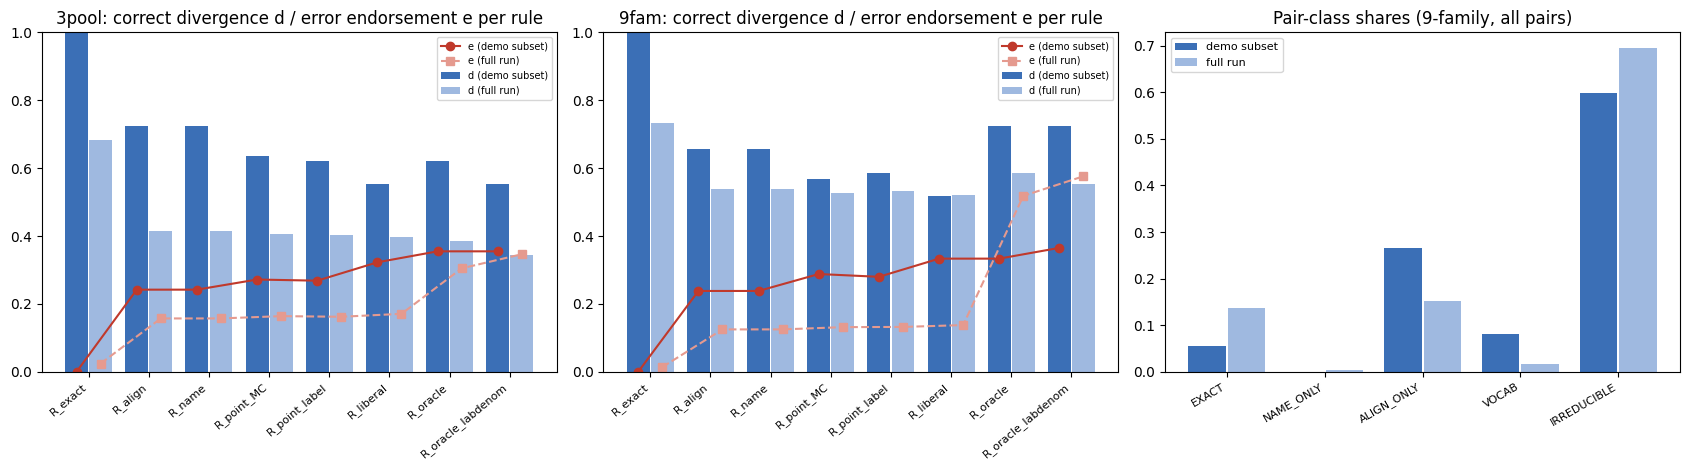

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(SHOW))
for ax, pool in zip(axes[:2], ("3pool", "9fam")):
    r = R[R.pool == pool]
    for off, col, lab, c in ((-0.2, "d_demo", "d (demo subset)", "#3b6fb6"), (0.2, "d_full", "d (full run)", "#9fb9e0")):
        ax.bar(x + off, r[col].astype(float), 0.38, label=lab, color=c)
    ax.plot(x - 0.2, r.e_demo.astype(float), "o-", color="#c0392b", label="e (demo subset)")
    ax.plot(x + 0.2, r.e_full.astype(float), "s--", color="#e59a8f", label="e (full run)")
    ax.set_xticks(x); ax.set_xticklabels(SHOW, rotation=40, ha="right", fontsize=8)
    ax.set_ylim(0, 1); ax.set_title(f"{pool}: correct divergence d / error endorsement e per rule")
    ax.legend(fontsize=7, loc="upper right")
cls_order = ["EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE"]
full_share = {"EXACT": 0.136, "NAME_ONLY": 0.003, "ALIGN_ONLY": 0.151, "VOCAB": 0.016, "IRREDUCIBLE": 0.694}  # 9-family, from the artifact summary
demo_share = Q.cls.value_counts(normalize=True).reindex(cls_order, fill_value=0)
xx = np.arange(len(cls_order))
axes[2].bar(xx - 0.2, demo_share.values, 0.38, label="demo subset", color="#3b6fb6")
axes[2].bar(xx + 0.2, [full_share[c] for c in cls_order], 0.38, label="full run", color="#9fb9e0")
axes[2].set_xticks(xx); axes[2].set_xticklabels(cls_order, rotation=30, ha="right", fontsize=8)
axes[2].set_title("Pair-class shares (9-family, all pairs)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Takeaway (full run).** Most cross-family disagreement is IRREDUCIBLE (69%). VOCAB pairs are rare (1.6%) and are not label-specific (placebo ratio ≈ 1–2 with a wide CI). Counting them as agreement lowers d by only about 0.01–0.02 and raises e. The pre-registered "gap closed" rule is ill-conditioned: its denominator is 0.013. Shared vocabulary alone therefore cannot fix consensus blind spots on E. PART 2 of the artifact adds a caveat: on R_COMP these instruments *under*-count what an actually shared signature does (calibration error −0.37).